# Patient Embeddings

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import torch
import pandas as pd
import seaborn as sns

import src.haplosaurus as hs
import src.ESM3 as ESM3
import src.onekg as ok
import src.utils as utils
import src.tensor_factorization as tf
import src.autoencoder as ae

/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## List embeddings

In [3]:
# Get a list of all the tx_ids in the embeddings directory
embeddings_dir = "/home/schilder/projects/data/1000_Genomes_on_GRCh38/haplotype_embeddings/ESMplusplus_small"

tx_ids = hs.list_haplotypes(cache=embeddings_dir,
                            suffix='.pth')

Found haplotypes of 47326 transcripts in: '/home/schilder/projects/data/1000_Genomes_on_GRCh38/haplotype_embeddings/ESMplusplus_small'


### Reconstruct patients

In [8]:
tensor_dict = ESM3.make_patient_tensor(
    haplotype_embeddings=embeddings_dir,
    tx_ids=tx_ids[:10],
    save_path="/home/schilder/projects/data/1000_Genomes_on_GRCh38/tensor_dict.pth"
    )

Getting max embedding dimension:   0%|          | 0/5 [00:00<?, ?it/s]

Max embedding dimension: 1920
Max embedding dimension: 1920
Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


TypeError: object of type 'NoneType' has no len()

In [ ]:
# Initialize model
model = ae.make_autoencoder(input_dim=tensor_dict['tensor'].shape[-1])

# Get total number of model parameters
sum(p.numel() for p in model.parameters())

<generator object Module.parameters at 0x7f3ed78efd80>

In [ ]:
torch.cuda.set_device(1)

model, history = ae.train_autoencoder(
    patient_tensor=tensor_dict['tensor'],
     model=model,
     batch_size=64*3,
     num_epochs=10,
     save_path="/home/schilder/projects/data/1000_Genomes_on_GRCh38/ae_out.pth"
    )

Epochs completed:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
torch.cuda.set_device(1)

encoded_tensor = ae.encode_patient_tensor(model=model,
                                          tensor_dict['tensor'])

In [37]:
utils.save_torch(encoded_tensor, ) 

Saving ==> /home/schilder/projects/data/1000_Genomes_on_GRCh38/encoded_tensor.pth


In [33]:
print(encoded_tensor.shape)

(model, 
embedding, 
nan_indices) = utils.run_umap(X=encoded_tensor)

tensor([[-0.0898,  0.0716, -0.0859,  ...,  0.0868,  0.0401, -0.0358],
        [-0.0898,  0.0716, -0.0859,  ...,  0.0868,  0.0401, -0.0358],
        [-0.0903,  0.0715, -0.0866,  ...,  0.0868,  0.0405, -0.0358],
        ...,
        [-0.0903,  0.0715, -0.0866,  ...,  0.0868,  0.0405, -0.0358],
        [-0.0903,  0.0715, -0.0866,  ...,  0.0868,  0.0405, -0.0358],
        [-0.0898,  0.0716, -0.0859,  ...,  0.0868,  0.0401, -0.0359]])
Filtering matrix
Matrix shape before filtering: torch.Size([2504, 32])
Matrix shape after filtering: torch.Size([2504, 32])
Running UMAP


/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Apr 17 19:50:04 2025 Construct fuzzy simplicial set
Thu Apr 17 19:50:06 2025 Finding Nearest Neighbors
Thu Apr 17 19:50:11 2025 Finished Nearest Neighbor Search
Thu Apr 17 19:50:13 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Apr 17 19:50:16 2025 Finished embedding


/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [34]:
sample_metadata = ok.get_sample_metadata()

umap_df = pd.DataFrame(embedding, 
                       columns=['UMAP_1', 'UMAP_2'],
                       index=list(tensor_dict['samples'])
                       ).merge(sample_metadata, 
                               left_index=True, 
                               right_index=True)
umap_df.head()

,UMAP_1,UMAP_2,Family ID,Individual ID,Paternal ID,Maternal ID,Gender,Phenotype,Population,Relationship,...,affy_genotypes,Population Description,Population Code,Super Population,DNA from Blood,Offspring available from trios,Pilot Samples,Phase1 Samples,Final Phase Samples,Total
HG02086,11.866184,1.486324,VN070,HG02086,0,0,2,0,KHV,unrel,...,1,"Kinh in Ho Chi Minh City, Vietnam",KHV,EAS,yes,yes,0.0,0.0,101.0,101.0
NA19758,9.949269,-1.348996,m027,NA19758,0,0,2,0,MXL,mother,...,1,"Mexican Ancestry in Los Angeles, California",MXL,AMR,no,yes,0.0,66.0,67.0,69.0
HG03854,-5.688852,-0.425929,ST094,HG03854,0,0,1,0,STU,father,...,1,Sri Lankan Tamil in the UK,STU,SAS,yes,yes,0.0,0.0,103.0,103.0
HG03052,10.337633,-1.376157,SL01,HG03052,0,0,2,0,MSL,mother,...,1,Mende in Sierra Leone,MSL,AFR,no,yes,0.0,0.0,85.0,85.0
NA21126,-7.257110,3.606825,NA21126,NA21126,0,0,1,0,GIH,unrel,...,1,"Gujarati Indian in Houston,TX",GIH,SAS,no,yes,0.0,0.0,106.0,106.0


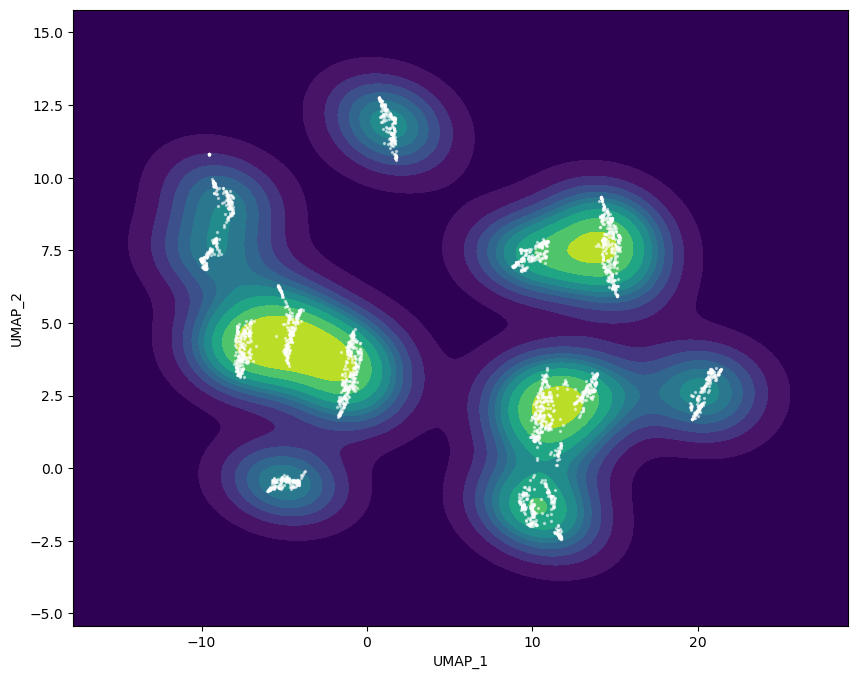

In [35]:
utils.plot_density(df=umap_df, 
                    x='UMAP_1', 
                    y='UMAP_2', 
                    alpha=0.5, 
                    s=2,
                    # hue='Super Population',
                    # color=None,
                    cmap='viridis', 
                    figsize=(10, 8)
                    )

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

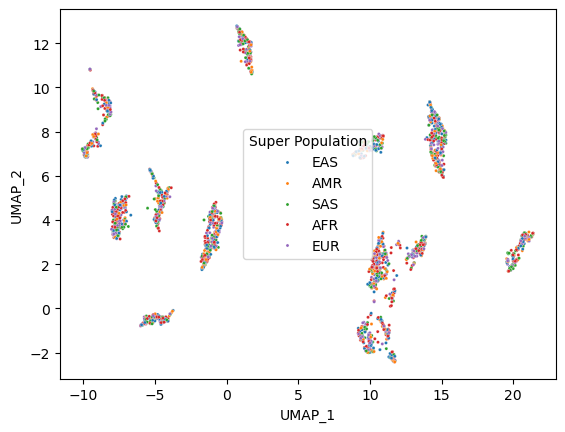

In [36]:
import seaborn as sns
sns.scatterplot(data=umap_df,
                x='UMAP_1', y='UMAP_2',
                alpha=1, # Make points semi-transparent
                s=5, # Small point size
                hue='Super Population',
                color=None,
                facecolor=None,
                )

### Tensor Factorization

In [ ]:
factors = tf.run_tensor_factorization(patient_tensor=tensor_dict['tensor'],
                                      n_components=50,
                                      n_epochs=100)

In [240]:
tx_contrib_df, l2_contrib_df = tf.get_tx_contributions(factors,
                                                        tensor_dict=tensor_dict)

In [241]:
print(tx_contrib_df.head().iloc[:,:5])
print(l2_contrib_df.head())

         ENST00000262367  ENST00000270162  ENST00000310373  ENST00000301305  \
NA20527       121.654846        46.867332       275.821289       -14.793362   
HG04093       169.445435       124.179802       -75.876617       -56.257248   
HG01242        36.965843       -90.485207      -100.122734       -69.969009   
HG02047       -75.819580       130.431824      -110.960052       104.013962   
HG04229       -89.473450        15.000725        35.589119        31.680601   

         ENST00000308192  
NA20527      -161.922577  
HG04093      -198.231201  
HG01242       186.928665  
HG02047      -106.799164  
HG04229         7.617838  
                 contribution
ENST00000299441      1.000000
ENST00000315576      0.879981
ENST00000367573      0.752647
ENST00000252034      0.744816
ENST00000265104      0.718345


In [239]:
clingen = pd.read_csv("https://search.clinicalgenome.org/kb/gene-validity/download",
            skiprows=range(4))
clingen = clingen.loc[~clingen["GENE SYMBOL"].str.startswith("+++")]
clingen['CLASSIFICATION'].value_counts()

classification_dict = {
    'Definitive': 5,
    'Strong': 4,
    'Moderate': 3,
    'Limited': 2,
    'Disputed':1,
    'No Known Disease Relationship':0,
    'Refuted':0,
}

clingen['classification_score'] = clingen['CLASSIFICATION'].map(classification_dict)
clingen.head()

clingen_scores = clingen.groupby('GENE SYMBOL')['classification_score'].sum().sort_values(ascending=False)
clingen_scores.head(10)


GENE SYMBOL
COL2A1     46
COL1A1     38
FGFR3      36
COL1A2     34
HBB        30
SLC26A2    20
FGFR2      20
TTN        20
ALPL       20
SCN5A      20
Name: classification_score, dtype: int64

In [251]:
import src.gprofiler as gp

l2_contrib_df = gp.map_ids(df=l2_contrib_df.reset_index(names=['ENST']),
                 on_left='ENST',
                 target_namespace="ENSG")
l2_contrib_df

,ENST,contribution,ENSG,HGNC
0,ENST00000299441,1.000000,ENSG00000166341,DCHS1
1,ENST00000315576,0.879981,ENSG00000127507,ADGRE2
2,ENST00000367573,0.752647,ENSG00000198216,CACNA1E
3,ENST00000252034,0.744816,ENSG00000049540,ELN
4,ENST00000265104,0.718345,ENSG00000039139,DNAH5
...,...,...,...,...
233,ENST00000261799,0.194610,ENSG00000113721,PDGFRB
234,ENST00000324048,0.189491,ENSG00000143373,ZNF687
235,ENST00000246914,0.186241,ENSG00000126562,WNK4
236,ENST00000352993,0.183235,ENSG00000012048,BRCA1


In [254]:
l2_contrib_clingen = l2_contrib_df.merge(
    pd.DataFrame(clingen_scores).reset_index(),
    left_on='HGNC',
    right_on='GENE SYMBOL',
    how='inner')

l2_contrib_clingen

,ENST,contribution,ENSG,HGNC,GENE SYMBOL,classification_score
0,ENST00000299441,1.000000,ENSG00000166341,DCHS1,DCHS1,4
1,ENST00000367573,0.752647,ENSG00000198216,CACNA1E,CACNA1E,5
2,ENST00000252034,0.744816,ENSG00000049540,ELN,ELN,5
3,ENST00000265104,0.718345,ENSG00000039139,DNAH5,DNAH5,5
4,ENST00000216181,0.685462,ENSG00000100345,MYH9,MYH9,5
...,...,...,...,...,...,...
119,ENST00000340083,0.202753,ENSG00000175920,DOK7,DOK7,5
120,ENST00000355832,0.200077,ENSG00000225830,ERCC6,ERCC6,5
121,ENST00000310775,0.198507,ENSG00000140525,FANCI,FANCI,5
122,ENST00000352993,0.183235,ENSG00000012048,BRCA1,BRCA1,10


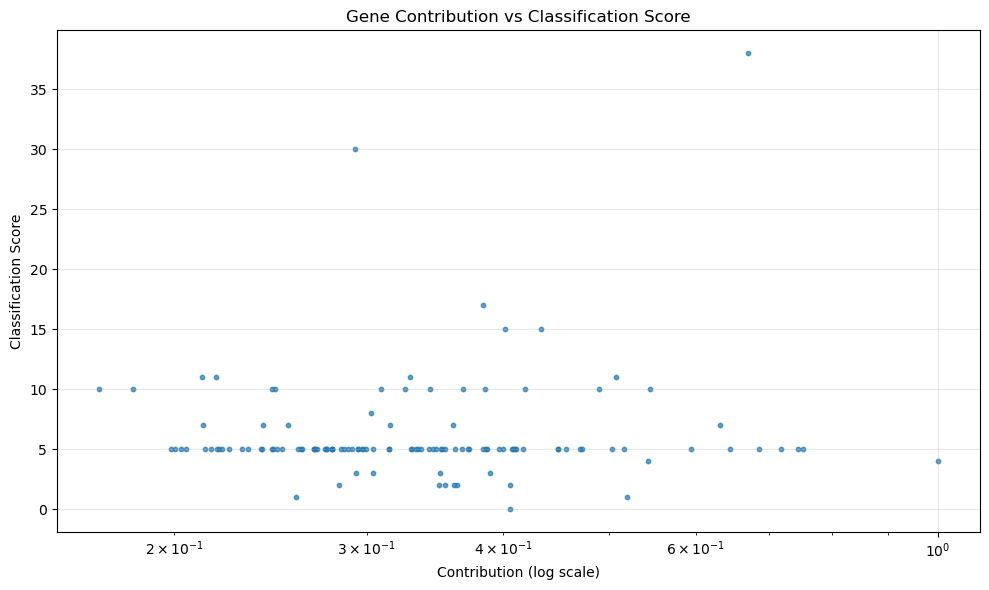

In [ ]:
sns.scatterplot(data=l2_contrib_clingen,
                x='contribution', y='classification_score',
                s=10)


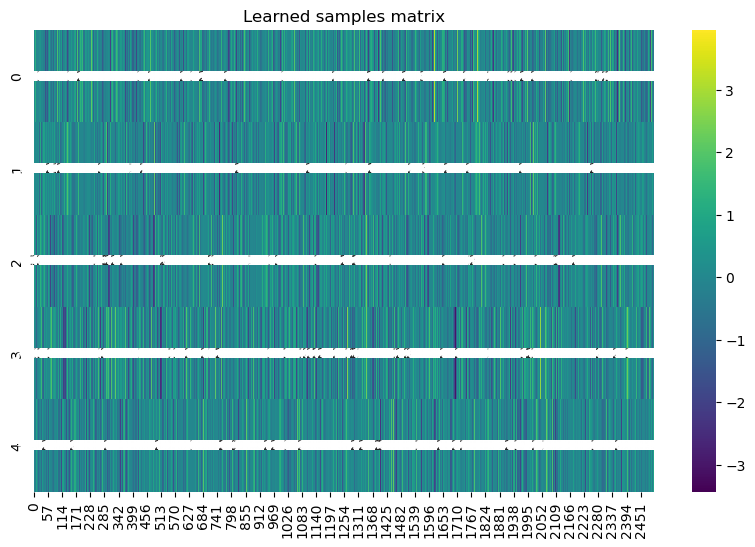

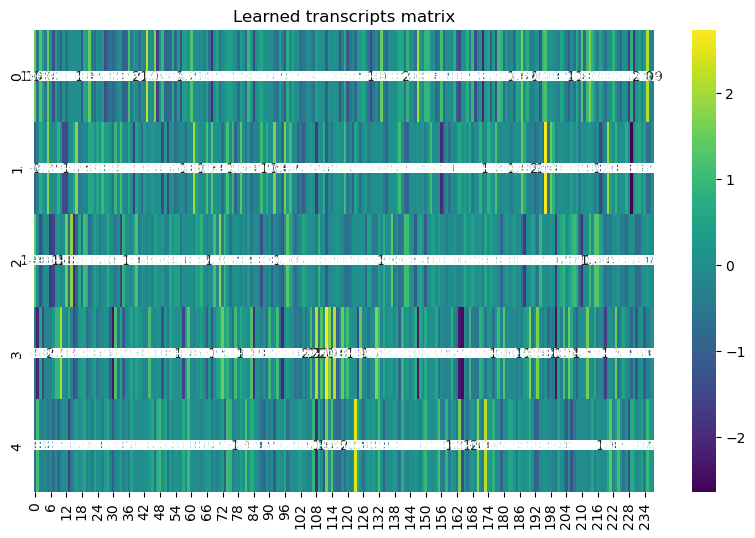

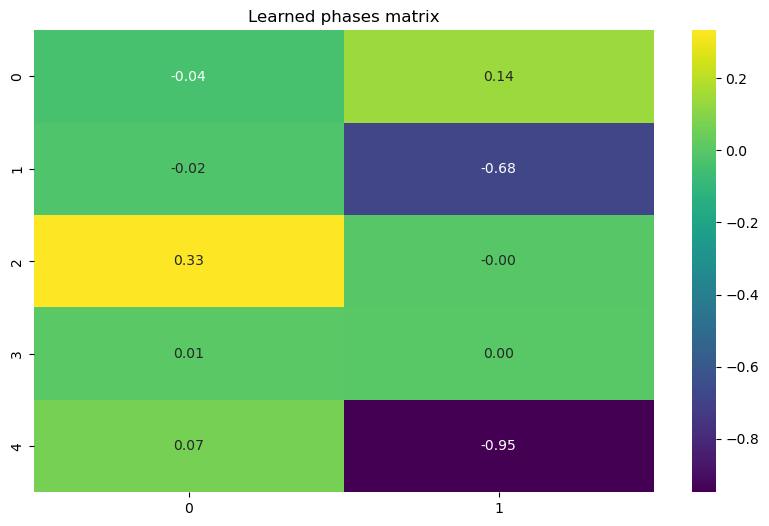

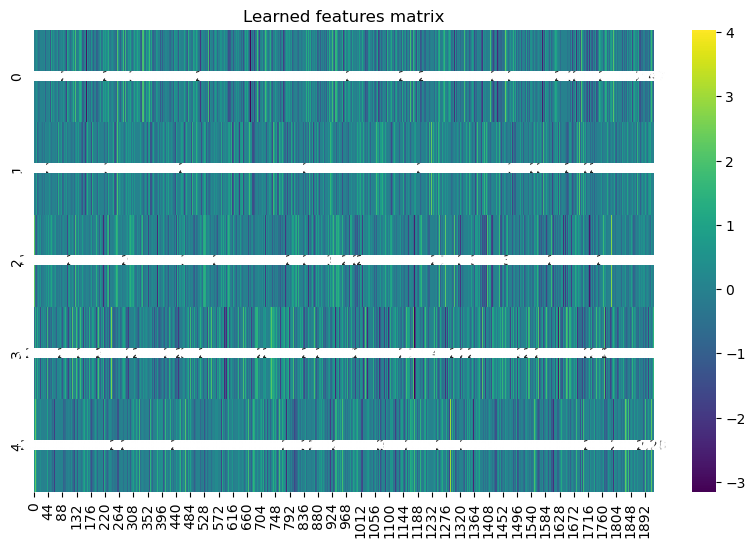

In [133]:
tf.plot_tensor_factorization(factors, 
                             max_factors=5)

In [134]:
print(factors['samples'].shape)

(model, 
embedding, 
nan_indices) = utils.run_umap(X=factors['samples'])

torch.Size([2504, 100])
Filtering matrix
Matrix shape before filtering: torch.Size([2504, 100])
Matrix shape after filtering: torch.Size([2504, 100])
Running UMAP
UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Apr 17 16:20:16 2025 Construct fuzzy simplicial set


/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Apr 17 16:20:19 2025 Finding Nearest Neighbors
Thu Apr 17 16:20:19 2025 Finished Nearest Neighbor Search
Thu Apr 17 16:20:19 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Apr 17 16:20:22 2025 Finished embedding


/home/schilder/.conda/envs/esm3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [138]:
sample_metadata = ok.get_sample_metadata()

umap_df = pd.DataFrame(embedding, 
                       columns=['UMAP_1', 'UMAP_2'],
                       index=list(tensor_dict['samples'])
                       ).merge(sample_metadata, 
                               left_index=True, 
                               right_index=True)
umap_df.head()

,UMAP_1,UMAP_2,Family ID,Individual ID,Paternal ID,Maternal ID,Gender,Phenotype,Population,Relationship,...,affy_genotypes,Population Description,Population Code,Super Population,DNA from Blood,Offspring available from trios,Pilot Samples,Phase1 Samples,Final Phase Samples,Total
NA20527,4.269620,6.789355,NA20527,NA20527,0,0,1,0,TSI,unrel,...,1,Toscani in Italy,TSI,EUR,no,no,66.0,98.0,108.0,110.0
HG04093,4.875285,4.080886,IT199,HG04093,0,0,1,0,ITU,father,...,1,Indian Telugu in the UK,ITU,SAS,yes,yes,0.0,0.0,103.0,103.0
HG01242,3.098590,6.007052,PR22,HG01242,0,0,2,0,PUR,mother,...,1,Puerto Rican in Puerto Rico,PUR,AMR,yes,yes,0.0,55.0,105.0,105.0
HG02047,5.787711,6.140159,VN056,HG02047,0,0,1,0,KHV,unrel,...,1,"Kinh in Ho Chi Minh City, Vietnam",KHV,EAS,yes,yes,0.0,0.0,101.0,101.0
HG04229,5.196541,6.213687,ST232,HG04229,0,0,1,0,STU,father,...,1,Sri Lankan Tamil in the UK,STU,SAS,yes,yes,0.0,0.0,103.0,103.0


In [139]:
umap_df['Super Population'].value_counts()

Super Population
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64

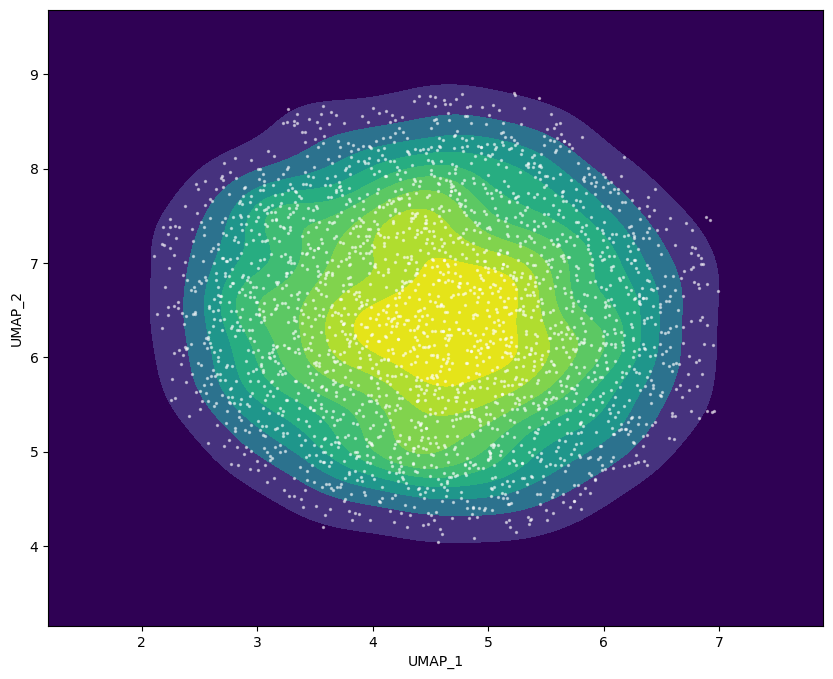

In [140]:
utils.plot_density(df=umap_df, 
                    x='UMAP_1', 
                    y='UMAP_2', 
                    alpha=0.5, 
                    s=2,
                    # hue='Super Population',
                    # color=None,
                    cmap='viridis', 
                    figsize=(10, 8)
                    )

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

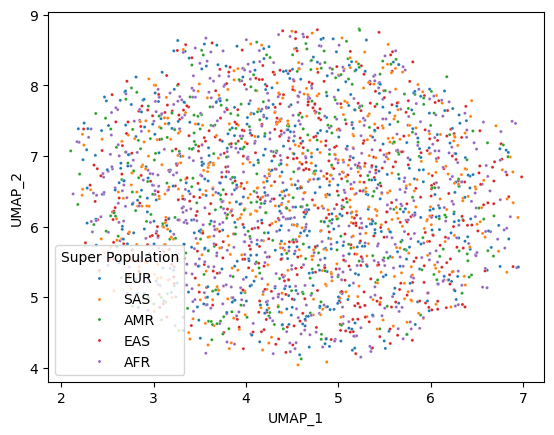

In [141]:
import seaborn as sns
sns.scatterplot(data=umap_df,
                x='UMAP_1', y='UMAP_2',
                alpha=1, # Make points semi-transparent
                s=5, # Small point size
                hue='Super Population',
                color=None,
                facecolor=None,
                )